In [10]:

import numpy as np # linear algebra
import pandas as pd 

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


import kagglehub

/kaggle/input/datasets/ankitsingh3k/phising/phishing.csv


In [11]:
# libraries....
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")

In [12]:
df = pd.read_csv("/kaggle/input/datasets/ankitsingh3k/phising/phishing.csv")
print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [13]:
df.head()
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])
print(df.columns)
df.info()
df.isnull().sum()

Rows : 11054
Columns : 32
Index(['Index', 'UsingIP', 'LongURL', 'ShortURL', 'Symbol@', 'Redirecting//',
       'PrefixSuffix-', 'SubDomains', 'HTTPS', 'DomainRegLen', 'Favicon',
       'NonStdPort', 'HTTPSDomainURL', 'RequestURL', 'AnchorURL',
       'LinksInScriptTags', 'ServerFormHandler', 'InfoEmail', 'AbnormalURL',
       'WebsiteForwarding', 'StatusBarCust', 'DisableRightClick',
       'UsingPopupWindow', 'IframeRedirection', 'AgeofDomain', 'DNSRecording',
       'WebsiteTraffic', 'PageRank', 'GoogleIndex', 'LinksPointingToPage',
       'StatsReport', 'class'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11054 entries, 0 to 11053
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Index                11054 non-null  int64
 1   UsingIP              11054 non-null  int64
 2   LongURL              11054 non-null  int64
 3   ShortURL             11054 non-null  int64
 4   Sym

Index                  0
UsingIP                0
LongURL                0
ShortURL               0
Symbol@                0
Redirecting//          0
PrefixSuffix-          0
SubDomains             0
HTTPS                  0
DomainRegLen           0
Favicon                0
NonStdPort             0
HTTPSDomainURL         0
RequestURL             0
AnchorURL              0
LinksInScriptTags      0
ServerFormHandler      0
InfoEmail              0
AbnormalURL            0
WebsiteForwarding      0
StatusBarCust          0
DisableRightClick      0
UsingPopupWindow       0
IframeRedirection      0
AgeofDomain            0
DNSRecording           0
WebsiteTraffic         0
PageRank               0
GoogleIndex            0
LinksPointingToPage    0
StatsReport            0
class                  0
dtype: int64

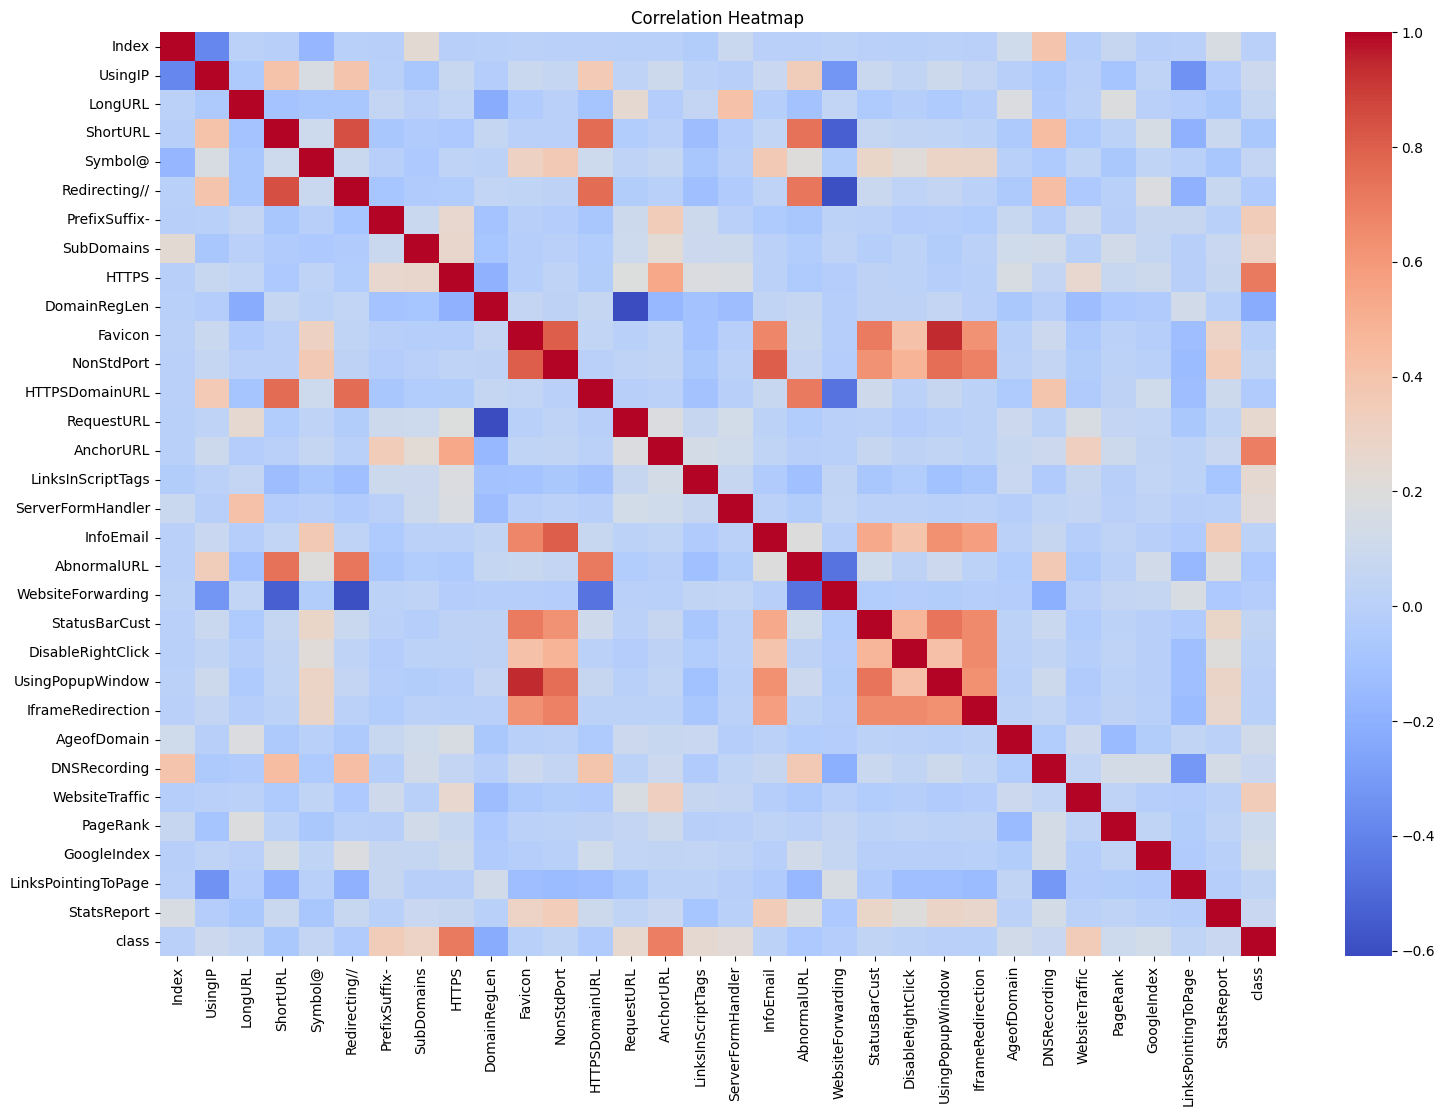

(11054, 31)
(11054,)


In [15]:
plt.figure(figsize=(18,12))

sns.heatmap(df.corr(), cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()
X = df.drop("class", axis=1)

y = df["class"]

print(X.shape)
print(y.shape)

In [16]:
#split data ser
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.20, random_state=42)

print("Training Data :", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data : (8843, 31)
Testing Data : (2211, 31)


In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [18]:
# saving model

import joblib

Accuracy : 0.5585707824513795
Precision : 0.5585707824513795
Recall : 1.0
F1 Score : 0.7167730702263494

Classification Report

              precision    recall  f1-score   support

          -1       0.00      0.00      0.00       976
           1       0.56      1.00      0.72      1235

    accuracy                           0.56      2211
   macro avg       0.28      0.50      0.36      2211
weighted avg       0.31      0.56      0.40      2211



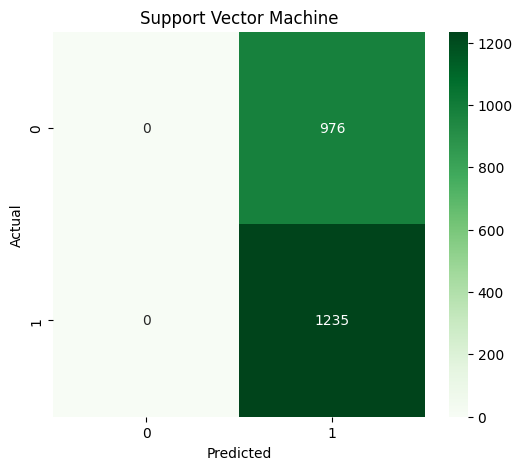

['svm_model.pkl']

In [19]:
# Support Vector Machine (SVM)

from sklearn.svm import SVC

svm_model = SVC(random_state=42)
svm_model.fit(X_train, y_train)
svm_prediction = svm_model.predict(X_test)

svm_accuracy = accuracy_score(y_test, svm_prediction)
svm_precision = precision_score(y_test, svm_prediction)
svm_recall = recall_score(y_test, svm_prediction)
svm_f1 = f1_score(y_test, svm_prediction)

print("Accuracy :", svm_accuracy)
print("Precision :", svm_precision)
print("Recall :", svm_recall)
print("F1 Score :", svm_f1)

print("\nClassification Report\n")
print(classification_report(y_test, svm_prediction))

svm_cm = confusion_matrix(y_test, svm_prediction)

plt.figure(figsize=(6,5))
sns.heatmap(
    svm_cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Support Vector Machine")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

joblib.dump(svm_model, "svm_model.pkl")

Accuracy : 0.9674
Precision : 0.9671
Recall : 0.9749
F1 Score : 0.971

Classification Report

              precision    recall  f1-score   support

           0       0.97      0.96      0.96       976
           1       0.97      0.97      0.97      1235

    accuracy                           0.97      2211
   macro avg       0.97      0.97      0.97      2211
weighted avg       0.97      0.97      0.97      2211



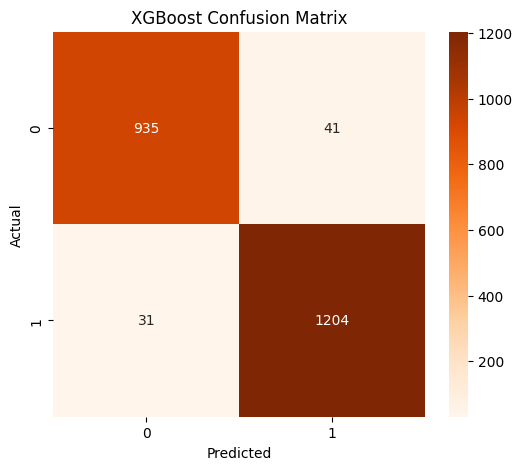

['xgboost_model.pkl']

In [20]:
# XGBoost Classifier

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score
from sklearn.metrics import recall_score, f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import joblib

y_train_xgb = y_train.replace(-1, 0)
y_test_xgb = y_test.replace(-1, 0)

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)
xgb_model.fit(X_train, y_train_xgb)

xgb_prediction = xgb_model.predict(X_test)

xgb_accuracy = accuracy_score(y_test_xgb, xgb_prediction)
xgb_precision = precision_score(y_test_xgb, xgb_prediction)
xgb_recall = recall_score(y_test_xgb, xgb_prediction)
xgb_f1 = f1_score(y_test_xgb, xgb_prediction)

print("Accuracy :", round(xgb_accuracy,4))
print("Precision :", round(xgb_precision,4))
print("Recall :", round(xgb_recall,4))
print("F1 Score :", round(xgb_f1,4))

print("\nClassification Report\n")
print(classification_report(y_test_xgb, xgb_prediction))

xgb_cm = confusion_matrix(y_test_xgb, xgb_prediction)

plt.figure(figsize=(6,5))

sns.heatmap(
    xgb_cm,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

joblib.dump(xgb_model, "xgboost_model.pkl")


Accuracy : 0.9697
Precision : 0.9695
Recall : 0.9765
F1 Score : 0.973

Classification Report

              precision    recall  f1-score   support

          -1       0.97      0.96      0.97       976
           1       0.97      0.98      0.97      1235

    accuracy                           0.97      2211
   macro avg       0.97      0.97      0.97      2211
weighted avg       0.97      0.97      0.97      2211



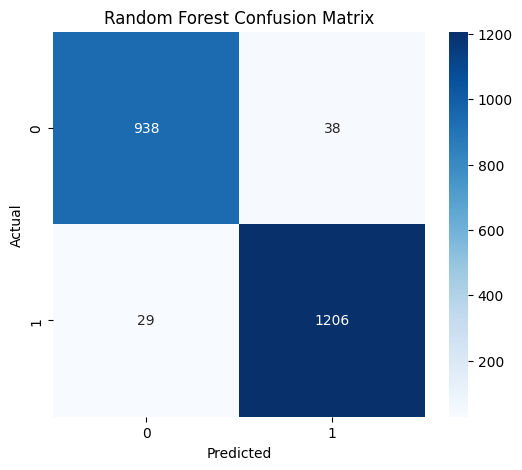

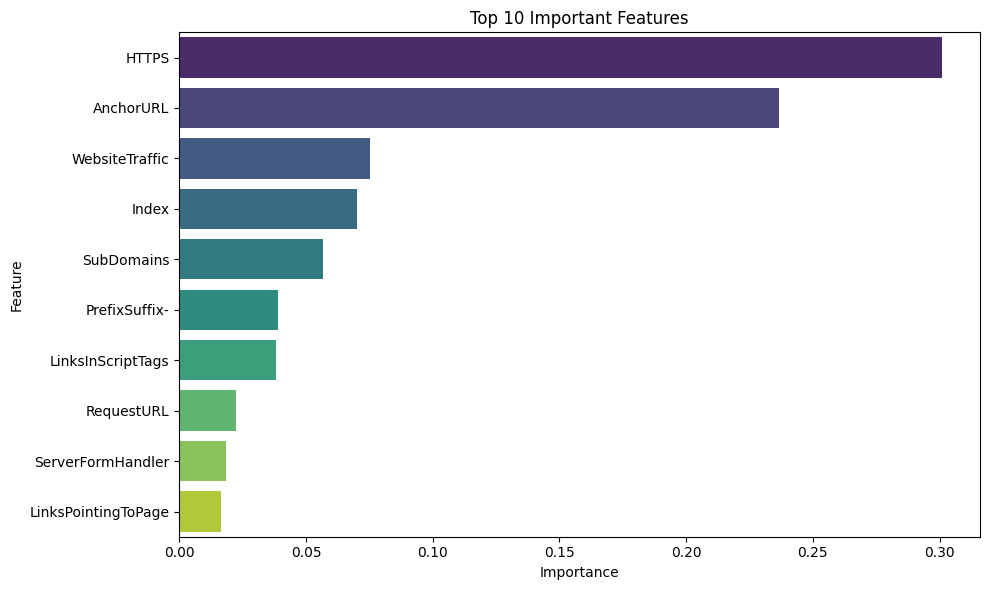


Random Forest model saved successfully!


In [21]:
# Random Forest Classifier

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score
from sklearn.metrics import recall_score, f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import joblib

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_prediction = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_prediction)
rf_precision = precision_score(y_test, rf_prediction)
rf_recall = recall_score(y_test, rf_prediction)
rf_f1 = f1_score(y_test, rf_prediction)

print("Accuracy :", round(rf_accuracy,4))
print("Precision :", round(rf_precision,4))
print("Recall :", round(rf_recall,4))
print("F1 Score :", round(rf_f1,4))

print("\nClassification Report\n")
print(classification_report(y_test, rf_prediction))

rf_cm = confusion_matrix(y_test, rf_prediction)

joblib.dump(rf_model, "random_forest_model.pkl")
plt.figure(figsize=(6,5))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Top 10 Important Features")
plt.tight_layout()
plt.show()

# Save Model
joblib.dump(rf_model, "random_forest_model.pkl")

print("\nRandom Forest model saved successfully!")

In [22]:
# Comparing All Models
comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Support Vector Machine",
        "XGBoost"
    ],

    "Accuracy": [
        rf_accuracy,
        svm_accuracy,
        xgb_accuracy
    ],

    "Precision": [
        rf_precision,
        svm_precision,
        xgb_precision
    ],

    "Recall": [
        rf_recall,
        svm_recall,
        xgb_recall
    ],

    "F1 Score": [
        rf_f1,
        svm_f1,
        xgb_f1
    ]

})

print("\n\nModel Comparison")

print(comparison)

print("\n")

best_model = comparison.loc[comparison["Accuracy"].idxmax()]

print("Best Performing Model")
print("----------------------------")
print("Model      :", best_model["Model"])
print("Accuracy   :", round(best_model["Accuracy"],4))
print("Precision  :", round(best_model["Precision"],4))
print("Recall     :", round(best_model["Recall"],4))
print("F1 Score   :", round(best_model["F1 Score"],4))



Model Comparison
                    Model  Accuracy  Precision    Recall  F1 Score
0           Random Forest  0.969697   0.969453  0.976518  0.972973
1  Support Vector Machine  0.558571   0.558571  1.000000  0.716773
2                 XGBoost  0.967436   0.967068  0.974899  0.970968


Best Performing Model
----------------------------
Model      : Random Forest
Accuracy   : 0.9697
Precision  : 0.9695
Recall     : 0.9765
F1 Score   : 0.973


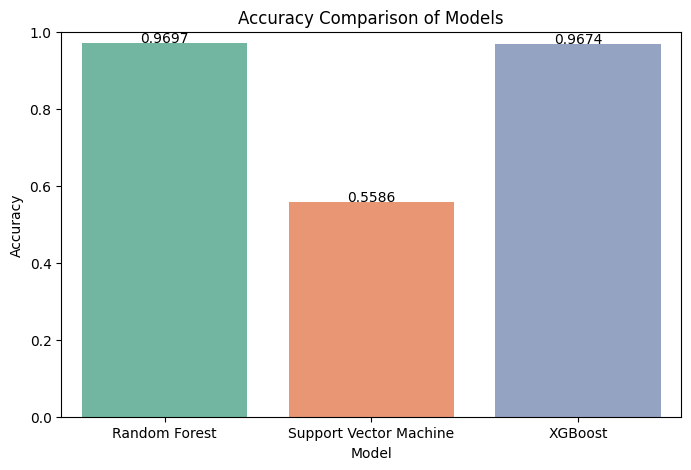

In [25]:
# Accuracy Comparison
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="Accuracy",
    palette="Set2"
)

plt.title("Accuracy Comparison of Models")
plt.ylim(0,1.0)

for index,value in enumerate(comparison["Accuracy"]):
    plt.text(index,value+0.002,round(value,4),ha="center")

plt.show()

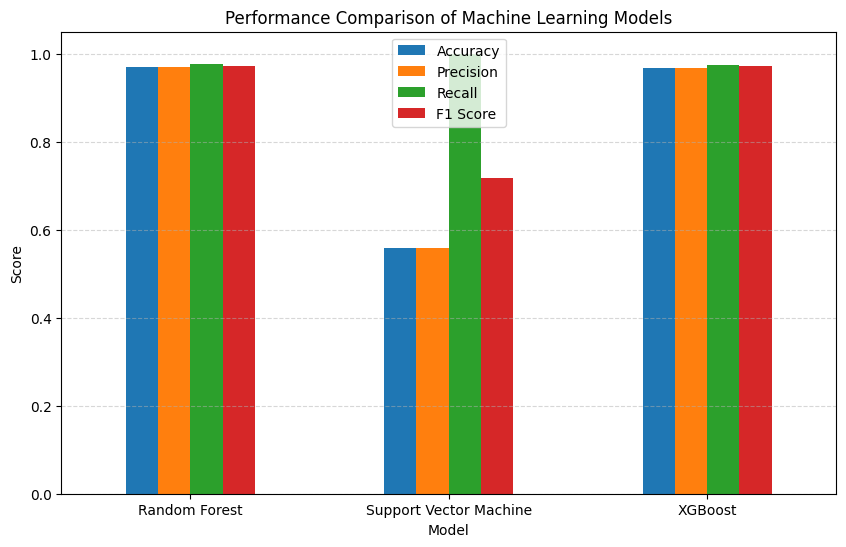

In [24]:
# Complete Performance Comparison

comparison.set_index("Model").plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Performance Comparison of Machine Learning Models")

plt.ylabel("Score")

plt.xticks(rotation=0)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()